# Financial Exposure and Lending Risk Analysis

## Objective

This part explains the bank's loan portfolio and repayment-risk profile.

Main questions:

- where loan exposure is concentrated
- which loan products are riskier
- how repayment status is distributed
- whether DTI, credit score, and LTV explain default behavior
- which relationship segments carry more loan risk
- where expected loss is concentrated

This uses the clean loan-level dataset from the preparation step.



## 1. Import Libraries and Load Loan-Level Data

We load `banking_customer_loan_analytics_clean.csv`, where each row represents one loan. This is the right table for exposure, repayment, and default-risk analysis.


In [1]:
# Basic libraries used in this notebook
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="darkgrid", palette="deep")

# Find the project folder automatically.
cwd = Path.cwd().resolve()
project_root = cwd
while project_root != project_root.parent and not (project_root / "data" / "processed").exists():
    project_root = project_root.parent

processed_dir = project_root / "data" / "processed"
tables_dir = project_root / "reports" / "tables"
figures_dir = project_root / "reports" / "figures" / "financial_exposure"

for folder in [tables_dir, figures_dir]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", project_root)
print("Processed data folder:", processed_dir)

# Load the loan-level clean dataset from EDA 1.
loan_data_path = processed_dir / "banking_customer_loan_analytics_clean.csv"
df = pd.read_csv(loan_data_path, parse_dates=["joined_bank", "loan_start_date"])

print(f"Loaded {len(df):,} loan records and {df.shape[1]} columns.")
df.head()


Project root: C:\tmp\Data_Analytics_publish_fresh\Projects\banking-customer-analytics
Processed data folder: C:\tmp\Data_Analytics_publish_fresh\Projects\banking-customer-analytics\data\processed
Loaded 11,911 loan records and 55 columns.


,loan_id,customer_id,loan_type,loan_amount,loan_term_months,interest_rate,loan_start_date,collateral_type,collateral_value,monthly_loan_payment,loan_purpose,credit_score,debt_to_income_ratio,loan_to_value_ratio,missed_payments_12m,days_past_due,repayment_status,default_flag,risk_band,expected_loss_amount,customer_name,age,gender,nationality,occupation,employment_status,city,state,banking_relationship,loyalty_classification,fee_structure,investment_advisor,joined_bank,annual_income,monthly_income,bank_deposits,checking_balance,savings_balance,credit_card_limit,credit_card_balance,credit_utilization_ratio,business_lending,existing_monthly_debt_payment,total_deposit_balance,deposit_to_income_ratio,age_group,income_band,customer_tenure_years,credit_utilization_band,credit_score_band,dti_band,ltv_band,has_recent_delinquency,loan_to_income_ratio,exposure_after_deposits
0,LOAN000001,CUST07874,Education Loan,"476,245.49",67,9.82,2023-08-14,Unsecured,0.00,"9,262.29",Higher Education,701.00,0.44,NaN,0,0,Current,0,Low,"11,667.54",Ira Gupta,25,Male,Indian,Retired,Self Employed,Hyderabad,Rajasthan,Retail,Gold,Standard,Advisor F,2000-08-24,"1,041,403.54","86,783.63","1,941,011.38","294,272.88","526,354.08","295,490.08","148,930.67",0.50,"32,633.27","26,618.51","2,761,638.34",2.65,18-25,Middle,25.90,Moderate,Good,35-45%,NaN,False,0.46,0.00
1,LOAN000002,CUST05835,Home Loan,"2,900,138.60",248,9.86,2021-08-08,Property,"4,143,693.51","27,434.77",Home Purchase,690.00,0.76,0.70,2,48,Current,0,Medium,"113,222.50",Pooja Das,47,Female,Indian,Shop Owner,Salaried,Hyderabad,Rajasthan,Private Bank,Jade,Discounted,Advisor C,2007-08-01,"721,199.00","60,099.92","822,640.31","78,310.11","367,728.34","174,594.15","15,283.32",0.09,"176,588.33","15,137.10","1,268,678.76",1.76,46-55,Lower Middle,19.00,Low,Good,>60%,60-80%,True,4.02,"1,631,459.84"
2,LOAN000003,CUST09330,Home Loan,"1,647,702.57",249,7.60,2021-05-21,Property,"2,622,794.55","13,169.82",Home Purchase,684.00,0.63,0.63,0,0,Current,0,Low,"41,793.69",Meera Chatterjee,42,Female,Indian,Consultant,Retired,Chennai,Gujarat,Private Bank,Silver,Premium,Advisor E,2001-07-12,"485,655.66","40,471.30","1,208,265.42","71,390.03","683,902.85","71,525.17","17,893.35",0.25,"309,393.35","11,688.61","1,963,558.30",4.04,36-45,Lower Middle,25.00,Low,Good,>60%,60-80%,False,3.39,0.00
3,LOAN000004,CUST03418,Business Loan,"2,737,180.44",73,12.84,2019-02-23,Unsecured,0.00,"54,217.24",Business Expansion,695.00,0.89,NaN,0,0,Current,0,Medium,"441,283.42",Shawn Kapoor,41,Female,Indian,Teacher,Self Employed,Lucknow,Rajasthan,Commercial,Gold,Standard,Advisor F,2009-08-14,"952,508.16","79,375.68","2,340,300.32","451,527.07","628,758.18","96,195.99","7,014.58",0.07,"780,822.00","17,865.78","3,420,585.57",3.59,36-45,Middle,16.90,Low,Good,>60%,NaN,False,2.87,0.00
4,LOAN000005,CUST07800,Auto Loan,"271,956.76",56,10.45,2021-02-03,Vehicle,"293,348.04","6,157.08",Vehicle Purchase,670.00,0.59,0.93,0,0,Current,0,Medium,"7,973.70",Shaurya Coleman,54,Female,Asian,Nurse,Salaried,Lucknow,Tamil Nadu,Retail,Silver,Standard,Advisor E,2022-03-13,"706,256.79","58,854.73","612,439.75","76,332.88","387,280.51","255,538.06","123,454.71",0.48,"180,130.14","21,623.57","1,076,053.14",1.52,46-55,Lower Middle,4.40,Moderate,Good,45-60%,80-95%,False,0.39,0.00


### Data Used

This part uses the loan-level table. Each row represents one loan, so loan counts, exposure totals, default rates, and expected loss calculations are based on loan records.



## 2. Portfolio-Level KPIs

This section gives the main overview of the bank's loan portfolio.


In [2]:
# High-level lending portfolio KPIs.
portfolio_kpis = pd.DataFrame([
    {"metric": "Loan records", "value": len(df)},
    {"metric": "Customers with loans", "value": df["customer_id"].nunique()},
    {"metric": "Total loan amount", "value": round(df["loan_amount"].sum(), 2)},
    {"metric": "Median loan amount", "value": round(df["loan_amount"].median(), 2)},
    {"metric": "Default rate percent", "value": round(df["default_flag"].mean() * 100, 2)},
    {"metric": "Expected loss", "value": round(df["expected_loss_amount"].sum(), 2)},
])

portfolio_kpis


,metric,value
0,Loan records,"11,911.00"
1,Customers with loans,"10,279.00"
2,Total loan amount,"24,607,156,879.19"
3,Median loan amount,"1,242,368.33"
4,Default rate percent,12.41
5,Expected loss,"1,991,652,792.67"


In [3]:
# Human-readable KPI table for reports/interview explanation.
portfolio_kpis_readable = pd.DataFrame([
    {"metric": "Loan records", "value": f"{len(df):,}"},
    {"metric": "Customers with loans", "value": f"{df['customer_id'].nunique():,}"},
    {"metric": "Total loan exposure", "value": f"INR {df['loan_amount'].sum() / 10_000_000:.2f} crore"},
    {"metric": "Median loan amount", "value": f"INR {df['loan_amount'].median():,.0f}"},
    {"metric": "Default rate", "value": f"{df['default_flag'].mean() * 100:.2f}%"},
    {"metric": "Expected loss", "value": f"INR {df['expected_loss_amount'].sum() / 10_000_000:.2f} crore"},
])

portfolio_kpis_readable


,metric,value
0,Loan records,"11,911"
1,Customers with loans,"10,279"
2,Total loan exposure,INR 2460.72 crore
3,Median loan amount,"INR 1,242,368"
4,Default rate,12.41%
5,Expected loss,INR 199.17 crore


### Portfolio KPIs

These numbers give the loan portfolio baseline: total exposure, default rate, median loan size, and expected loss before breaking the portfolio into products and risk groups.



## 3. Distribution Analysis

Before comparing segments, I check the shape of important numeric fields. This helps me understand skewness, spread, and unusual values in the lending portfolio.


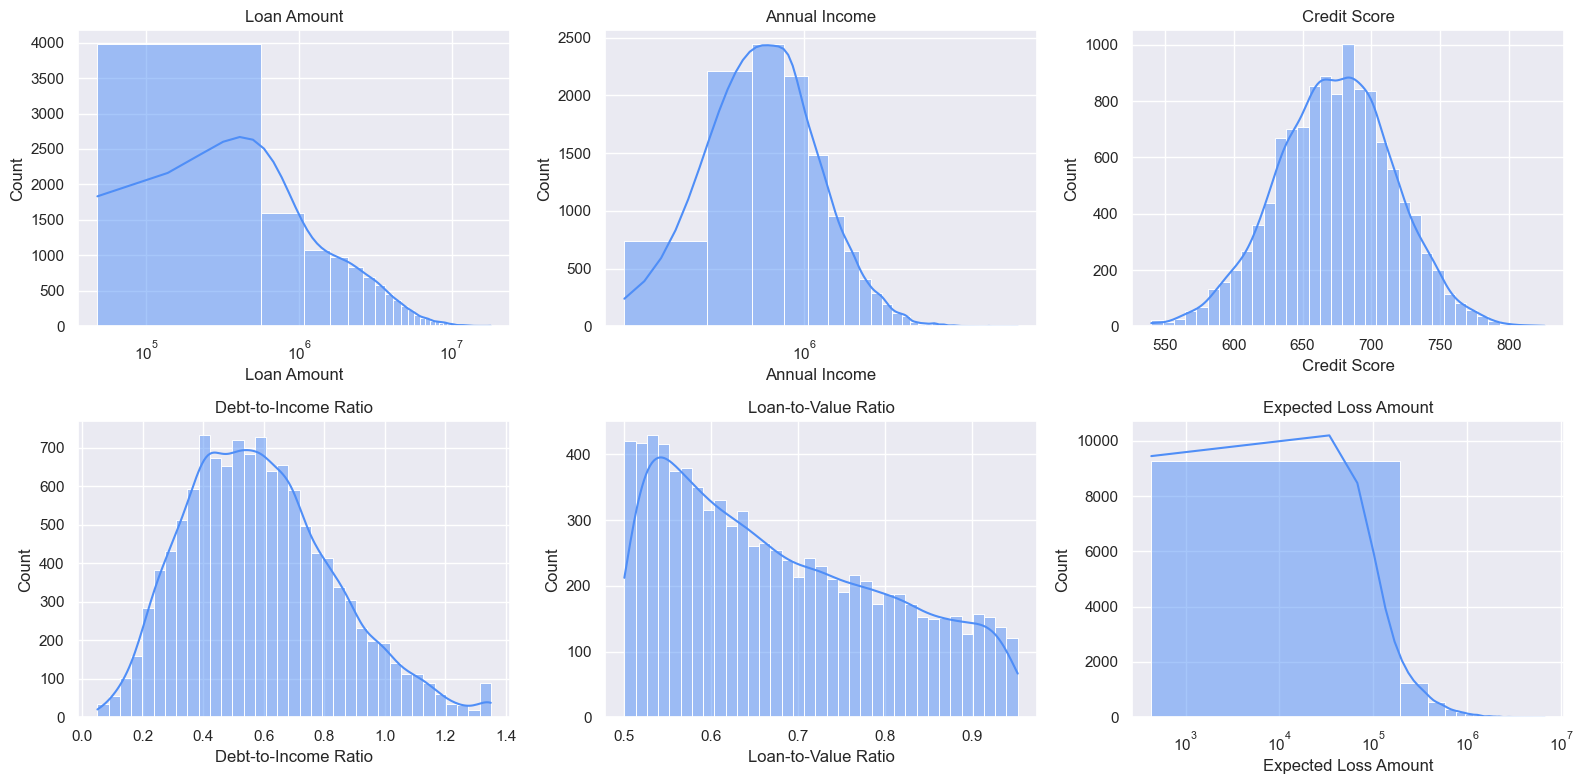

In [4]:
# Histograms/KDE for important lending-risk fields.
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

distribution_columns = [
    ("loan_amount", "Loan Amount", True),
    ("annual_income", "Annual Income", True),
    ("credit_score", "Credit Score", False),
    ("debt_to_income_ratio", "Debt-to-Income Ratio", False),
    ("loan_to_value_ratio", "Loan-to-Value Ratio", False),
    ("expected_loss_amount", "Expected Loss Amount", True),
]

for index, (column, title, use_log) in enumerate(distribution_columns):
    sns.histplot(df[column].dropna(), bins=35, kde=True, ax=axes[index], color="#4f8ef7")
    axes[index].set_title(title)
    axes[index].set_xlabel(title)
    if use_log:
        axes[index].set_xscale("log")

fig.tight_layout()
fig.savefig(figures_dir / "risk_distribution_checks.png", dpi=160, bbox_inches="tight")
plt.show()



In [5]:
# Simple numerical distribution summary.
risk_distribution_summary = df[[
    "loan_amount", "annual_income", "credit_score", "debt_to_income_ratio",
    "loan_to_value_ratio", "expected_loss_amount"
]].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).T

risk_distribution_summary



,count,mean,std,min,25%,50%,75%,90%,95%,max
loan_amount,"11,911.00","2,065,918.64","2,315,457.81","47,812.40","412,325.52","1,242,368.33","2,969,437.58","4,924,223.21","6,581,963.93","18,000,000.00"
annual_income,"11,911.00","1,001,923.68","568,308.17","180,000.00","612,107.65","874,386.72","1,236,603.08","1,715,432.77","2,089,955.67","7,701,302.64"
credit_score,"11,911.00",673.59,42.23,540.00,645.00,674.00,702.00,727.00,742.00,826.00
debt_to_income_ratio,"11,911.00",0.59,0.25,0.05,0.41,0.57,0.74,0.92,1.04,1.35
loan_to_value_ratio,"8,587.00",0.68,0.13,0.50,0.57,0.65,0.78,0.87,0.91,0.95
expected_loss_amount,"11,911.00","167,211.22","355,750.12",432.06,"9,162.55","39,994.74","162,308.61","455,991.89","761,264.14","6,681,004.38"


### Distribution Result

Loan amount, income, and expected loss are strongly right-skewed. This is normal in banking because a smaller group of borrowers can carry much larger loans and higher money-at-risk. Credit score and DTI are more useful as risk signals than simple averages.



## 4. Loan Product Exposure and Risk

This section compares loan products such as Home Loan, Business Loan, Personal Loan, Credit Line, Auto Loan, and Education Loan.

The key question is:

> Which product has the highest exposure, and which product has the highest default rate?


In [6]:
# Summarize exposure and risk by loan type.
loan_type_summary = (
    df.groupby("loan_type", observed=False)
    .agg(
        loans=("loan_id", "count"),
        total_exposure=("loan_amount", "sum"),
        median_loan=("loan_amount", "median"),
        default_rate=("default_flag", "mean"),
        avg_interest_rate=("interest_rate", "mean"),
        expected_loss=("expected_loss_amount", "sum"),
    )
    .reset_index()
)

loan_type_summary["default_rate"] = (loan_type_summary["default_rate"] * 100).round(2)
loan_type_summary["avg_interest_rate"] = loan_type_summary["avg_interest_rate"].round(2)
loan_type_summary = loan_type_summary.sort_values("total_exposure", ascending=False)
loan_type_summary


,loan_type,loans,total_exposure,median_loan,default_rate,avg_interest_rate,expected_loss
3,Home Loan,4565,"17,109,244,490.43","3,087,932.37",13.21,8.61,"1,060,504,965.98"
1,Business Loan,1929,"4,939,034,599.08","2,109,281.82",30.79,12.46,"849,427,806.89"
0,Auto Loan,2169,"1,225,358,422.77","463,663.98",5.72,10.18,"31,086,762.81"
4,Personal Loan,2527,"1,006,927,560.58","328,975.40",5.07,14.21,"39,672,138.01"
2,Education Loan,721,"326,591,806.33","361,225.48",4.02,11.31,"10,961,118.98"


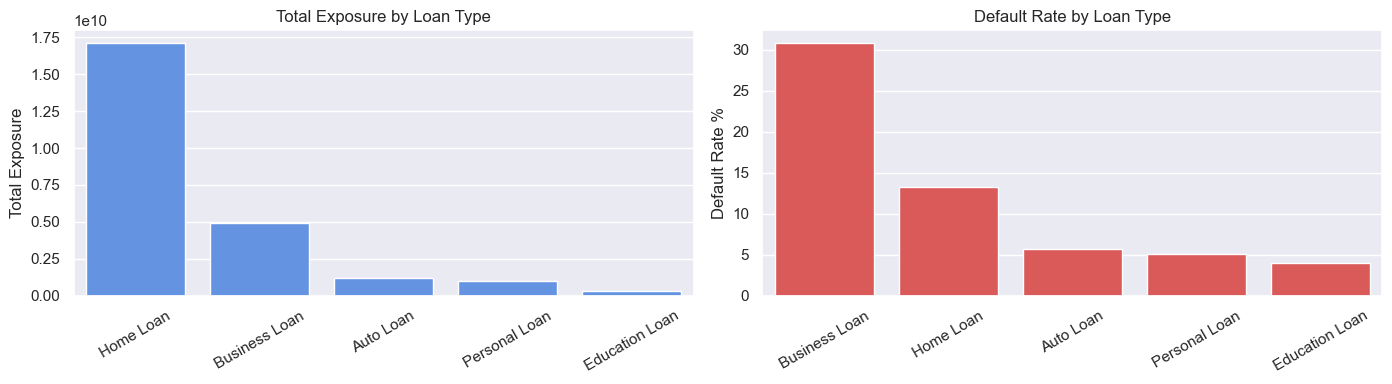

In [7]:
# Plot exposure and default rate by loan type.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(data=loan_type_summary, x="loan_type", y="total_exposure", ax=axes[0], color="#4f8ef7")
axes[0].set_title("Total Exposure by Loan Type")
axes[0].set_xlabel("")
axes[0].set_ylabel("Total Exposure")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=loan_type_summary.sort_values("default_rate", ascending=False), x="loan_type", y="default_rate", ax=axes[1], color="#ef4444")
axes[1].set_title("Default Rate by Loan Type")
axes[1].set_xlabel("")
axes[1].set_ylabel("Default Rate %")
axes[1].tick_params(axis="x", rotation=30)

fig.tight_layout()
fig.savefig(figures_dir / "loan_type_exposure_and_default_rate.png", dpi=160, bbox_inches="tight")
plt.show()


### Loan Product Result

This separates exposure concentration from risk concentration. A product can have high exposure but moderate default rate, while another product can have lower exposure but higher default rate.



## 5. Repayment Status Analysis

Repayment status shows whether loans are current, late, restructured, or defaulted.


In [8]:
# Repayment status summary.
repayment_summary = (
    df.groupby("repayment_status", observed=False)
    .agg(
        loans=("loan_id", "count"),
        total_exposure=("loan_amount", "sum"),
        expected_loss=("expected_loss_amount", "sum"),
    )
    .reset_index()
)

repayment_summary["loan_pct"] = (repayment_summary["loans"] / len(df) * 100).round(2)
repayment_summary = repayment_summary.sort_values("loans", ascending=False)
repayment_summary


,repayment_status,loans,total_exposure,expected_loss,loan_pct
0,Current,8725,"16,174,184,283.83","993,554,489.24",73.25
1,Defaulted,1297,"4,000,718,771.22","591,012,046.31",10.89
3,Paid Off,892,"1,585,285,293.80","88,942,827.80",7.49
2,Late,462,"1,265,908,472.76","123,091,449.68",3.88
4,Restructured,354,"1,029,817,238.18","106,309,377.99",2.97
5,Written Off,181,"551,242,819.40","88,742,601.65",1.52


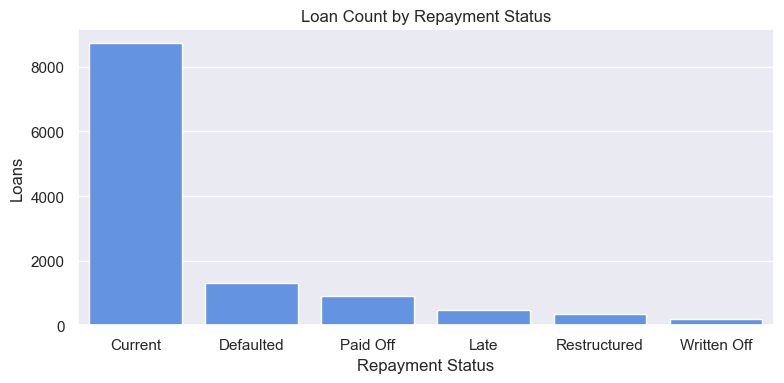

In [9]:
# Plot repayment status by loan count.
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=repayment_summary, x="repayment_status", y="loans", ax=ax, color="#4f8ef7")
ax.set_title("Loan Count by Repayment Status")
ax.set_xlabel("Repayment Status")
ax.set_ylabel("Loans")
fig.tight_layout()
fig.savefig(figures_dir / "repayment_status_distribution.png", dpi=160, bbox_inches="tight")
plt.show()


### Repayment Status Result

Repayment status shows current portfolio health. Current loans are healthy, Late and Restructured loans are warning groups, and Defaulted/Written Off loans represent stronger credit risk.



## 5. Portfolio Share Donut Charts

Tables are useful, but share charts make portfolio concentration easier to see. Here I check repayment status share and loan exposure share by product.


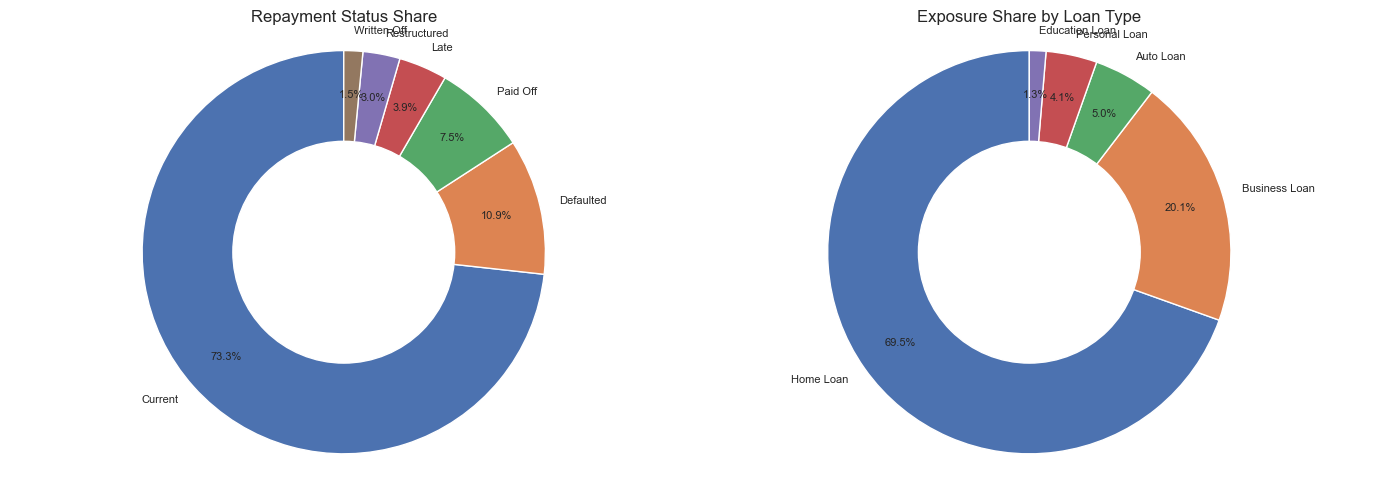

In [10]:
# Donut chart helper.
def plot_donut(ax, labels, values, title):
    wedges, texts, autotexts = ax.pie(
        values,
        labels=labels,
        autopct="%1.1f%%",
        startangle=90,
        pctdistance=0.78,
        textprops={"fontsize": 8},
    )
    centre_circle = plt.Circle((0, 0), 0.55, fc="white")
    ax.add_artist(centre_circle)
    ax.set_title(title)
    ax.axis("equal")

repayment_share = df["repayment_status"].value_counts()
exposure_share = df.groupby("loan_type", observed=False)["loan_amount"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_donut(axes[0], repayment_share.index, repayment_share.values, "Repayment Status Share")
plot_donut(axes[1], exposure_share.index, exposure_share.values, "Exposure Share by Loan Type")
fig.tight_layout()
fig.savefig(figures_dir / "repayment_and_exposure_donut_charts.png", dpi=160, bbox_inches="tight")
plt.show()



### Portfolio Share Result

The repayment chart shows most loans are current. The product exposure chart shows where the bank's money is concentrated by loan type.



## 6. Risk Band Analysis

Risk band gives an overall risk category for each loan. This section checks whether High, Medium, and Low risk bands separate default behavior correctly.


In [11]:
# Summarize portfolio by risk band.
risk_band_summary = (
    df.groupby("risk_band", observed=False)
    .agg(
        loans=("loan_id", "count"),
        total_exposure=("loan_amount", "sum"),
        median_credit_score=("credit_score", "median"),
        median_dti=("debt_to_income_ratio", "median"),
        median_ltv=("loan_to_value_ratio", "median"),
        default_rate=("default_flag", "mean"),
        expected_loss=("expected_loss_amount", "sum"),
    )
    .reset_index()
)

risk_band_summary["default_rate"] = (risk_band_summary["default_rate"] * 100).round(2)
risk_band_summary = risk_band_summary.sort_values("default_rate", ascending=False)
risk_band_summary


,risk_band,loans,total_exposure,median_credit_score,median_dti,median_ltv,default_rate,expected_loss
0,High,2144,"7,389,608,835.83",632.00,0.88,0.66,53.82,"1,140,581,973.81"
2,Medium,4288,"10,483,742,729.08",656.00,0.67,0.66,7.53,"706,216,438.09"
1,Low,5479,"6,733,805,314.28",700.00,0.41,0.65,0.02,"144,854,380.77"


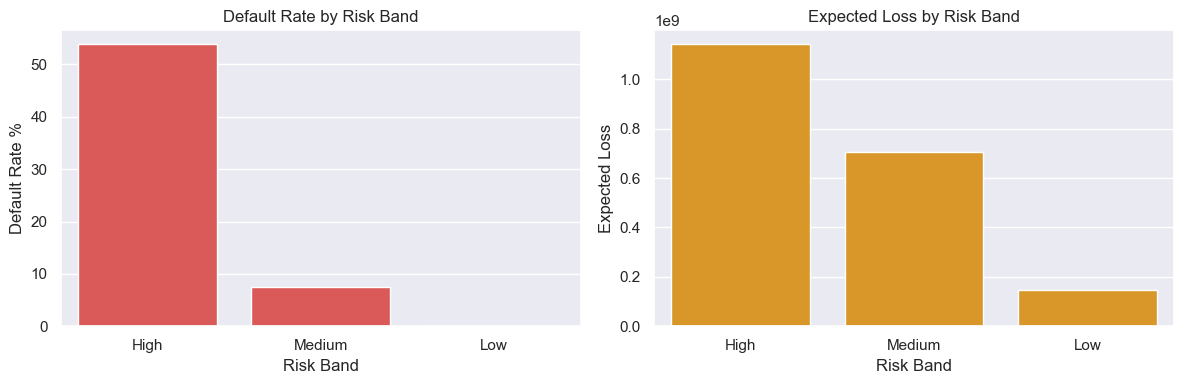

In [12]:
# Plot risk-band default rate and expected loss.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=risk_band_summary, x="risk_band", y="default_rate", ax=axes[0], color="#ef4444")
axes[0].set_title("Default Rate by Risk Band")
axes[0].set_xlabel("Risk Band")
axes[0].set_ylabel("Default Rate %")

sns.barplot(data=risk_band_summary, x="risk_band", y="expected_loss", ax=axes[1], color="#f59e0b")
axes[1].set_title("Expected Loss by Risk Band")
axes[1].set_xlabel("Risk Band")
axes[1].set_ylabel("Expected Loss")

fig.tight_layout()
fig.savefig(figures_dir / "risk_band_default_and_expected_loss.png", dpi=160, bbox_inches="tight")
plt.show()


### Risk Band Result

High-risk loans should have higher default rates and higher expected loss. This section checks whether the risk bands are meaningful in the data.



## 7. Boxplot Risk Checks

Boxplots help compare the spread of loan amount and DTI across risk groups. This gives more information than a simple average.


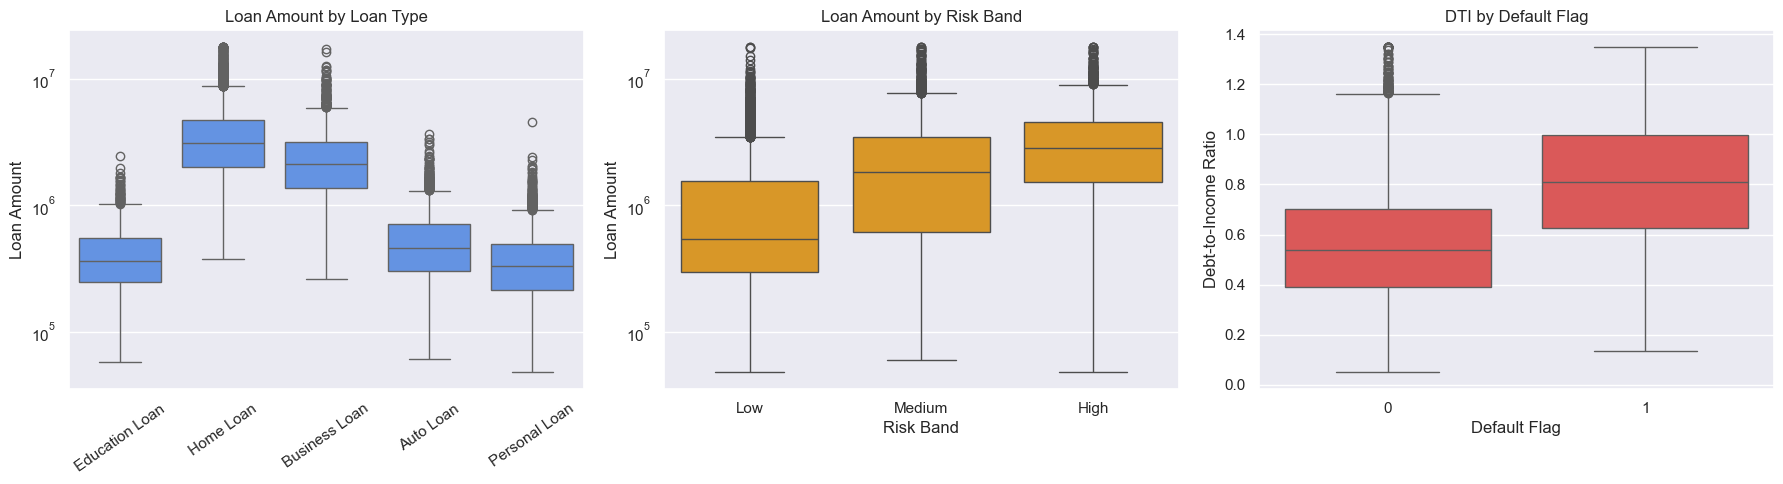

In [13]:
# Boxplots for loan amount by product and risk band, plus DTI by default flag.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x="loan_type", y="loan_amount", ax=axes[0], color="#4f8ef7")
axes[0].set_title("Loan Amount by Loan Type")
axes[0].set_xlabel("")
axes[0].set_ylabel("Loan Amount")
axes[0].set_yscale("log")
axes[0].tick_params(axis="x", rotation=35)

sns.boxplot(data=df, x="risk_band", y="loan_amount", ax=axes[1], color="#f59e0b")
axes[1].set_title("Loan Amount by Risk Band")
axes[1].set_xlabel("Risk Band")
axes[1].set_ylabel("Loan Amount")
axes[1].set_yscale("log")

sns.boxplot(data=df, x="default_flag", y="debt_to_income_ratio", ax=axes[2], color="#ef4444")
axes[2].set_title("DTI by Default Flag")
axes[2].set_xlabel("Default Flag")
axes[2].set_ylabel("Debt-to-Income Ratio")

fig.tight_layout()
fig.savefig(figures_dir / "loan_risk_boxplots.png", dpi=160, bbox_inches="tight")
plt.show()



### Boxplot Result

The boxplots show that large loans and high DTI values are not spread equally across groups. Defaulted loans sit in a riskier DTI range, so DTI is an important lending-risk feature.



## 8. Debt-to-Income Ratio Analysis

DTI measures debt burden compared to income. A high DTI means the borrower already has heavy repayment pressure.


In [14]:
# Default rate by DTI band.
default_by_dti = (
    df.groupby("dti_band", observed=False)
    .agg(
        loans=("loan_id", "count"),
        median_income=("annual_income", "median"),
        median_loan_amount=("loan_amount", "median"),
        default_rate=("default_flag", "mean"),
        expected_loss=("expected_loss_amount", "sum"),
    )
    .reset_index()
)

default_by_dti["default_rate"] = (default_by_dti["default_rate"] * 100).round(2)
default_by_dti


,dti_band,loans,median_income,median_loan_amount,default_rate,expected_loss
0,35-45%,1812,"857,180.70","535,532.32",3.86,"39,988,312.04"
1,45-60%,2785,"861,787.54","1,025,158.76",6.97,"146,388,824.51"
2,<=35%,2011,"848,739.55","366,794.35",2.93,"17,325,859.74"
3,>60%,5303,"885,515.62","2,488,847.84",21.78,"1,787,949,796.38"


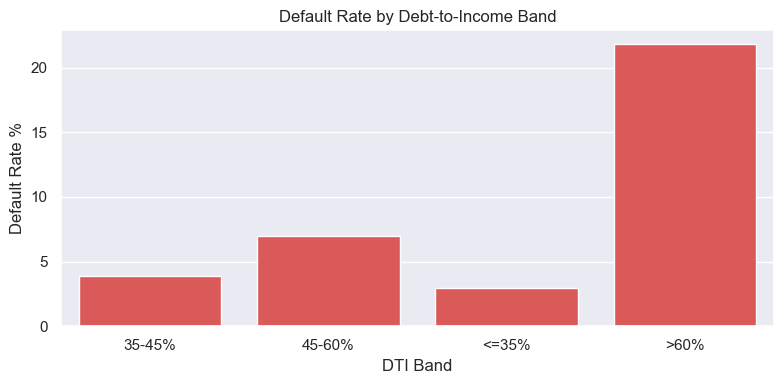

In [15]:
# Plot default rate by DTI band.
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=default_by_dti, x="dti_band", y="default_rate", ax=ax, color="#ef4444")
ax.set_title("Default Rate by Debt-to-Income Band")
ax.set_xlabel("DTI Band")
ax.set_ylabel("Default Rate %")
fig.tight_layout()
fig.savefig(figures_dir / "default_rate_by_dti_band.png", dpi=160, bbox_inches="tight")
plt.show()


### DTI Result

DTI is one of the clearest risk signals here. As DTI increases, default rate also increases, which makes DTI useful for loan review, pricing, and monitoring.



## 9. Credit Score Analysis

Credit score is a classic borrower-risk indicator. This section checks default rate across credit-score bands.


In [16]:
# Default rate by credit score band.
default_by_credit = (
    df.groupby("credit_score_band", observed=False)
    .agg(
        loans=("loan_id", "count"),
        median_dti=("debt_to_income_ratio", "median"),
        median_loan_amount=("loan_amount", "median"),
        default_rate=("default_flag", "mean"),
        expected_loss=("expected_loss_amount", "sum"),
    )
    .reset_index()
)

default_by_credit["default_rate"] = (default_by_credit["default_rate"] * 100).round(2)
default_by_credit


,credit_score_band,loans,median_dti,median_loan_amount,default_rate,expected_loss
0,Excellent,12,0.30,"426,133.91",0.00,"216,429.80"
1,Fair,5257,0.68,"1,884,448.68",19.21,"1,482,179,960.50"
2,Good,5782,0.49,"824,861.40",6.40,"353,204,931.73"
3,Poor,175,0.98,"3,114,025.46",42.86,"138,557,979.15"
4,Very Good,685,0.37,"517,374.23",3.36,"17,493,491.49"


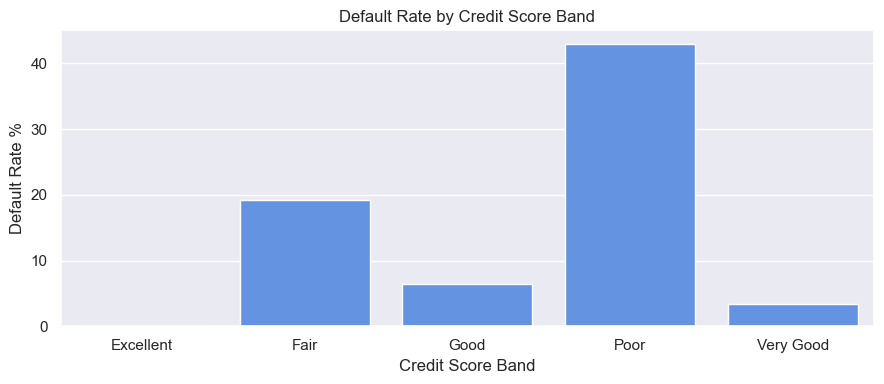

In [17]:
# Plot default rate by credit score band.
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=default_by_credit, x="credit_score_band", y="default_rate", ax=ax, color="#4f8ef7")
ax.set_title("Default Rate by Credit Score Band")
ax.set_xlabel("Credit Score Band")
ax.set_ylabel("Default Rate %")
fig.tight_layout()
fig.savefig(figures_dir / "default_rate_by_credit_score_band.png", dpi=160, bbox_inches="tight")
plt.show()


### Credit Score Result

Credit-score bands show whether weaker credit-score groups have higher default pressure. This is useful for underwriting and later feature selection.



## 10. Loan-to-Value Ratio Analysis

LTV compares the loan amount with collateral value. Higher LTV means less collateral protection for the bank.

Some loans are unsecured, so LTV may be missing for those records.


In [18]:
# Default rate by LTV band.
default_by_ltv = (
    df.groupby("ltv_band", observed=False)
    .agg(
        loans=("loan_id", "count"),
        median_loan_amount=("loan_amount", "median"),
        default_rate=("default_flag", "mean"),
        expected_loss=("expected_loss_amount", "sum"),
    )
    .reset_index()
)

default_by_ltv["default_rate"] = (default_by_ltv["default_rate"] * 100).round(2)
default_by_ltv


,ltv_band,loans,median_loan_amount,default_rate,expected_loss
0,60-80%,3741,"1,942,426.48",14.30,"690,076,439.79"
1,80-95%,1795,"1,889,384.53",14.71,"367,723,212.96"
2,<=60%,3038,"1,996,922.35",12.74,"536,391,873.81"
3,>95%,13,"2,710,519.11",23.08,"3,387,459.03"


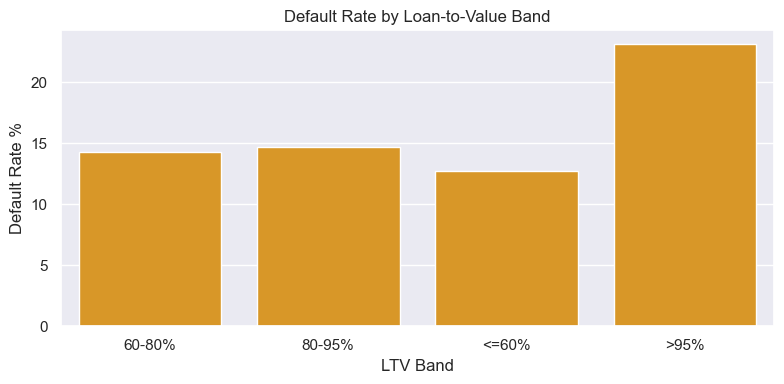

In [19]:
# Plot default rate by LTV band.
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=default_by_ltv, x="ltv_band", y="default_rate", ax=ax, color="#f59e0b")
ax.set_title("Default Rate by Loan-to-Value Band")
ax.set_xlabel("LTV Band")
ax.set_ylabel("Default Rate %")
fig.tight_layout()
fig.savefig(figures_dir / "default_rate_by_ltv_band.png", dpi=160, bbox_inches="tight")
plt.show()


### LTV Result

LTV helps explain collateral coverage for secured loans. Some LTV values are missing because unsecured products do not have collateral.



## 11. Delinquency Signal Analysis

Missed payments and days past due are direct warning signs. This section checks whether recent delinquency is connected with default risk.


In [20]:
# Compare loans with and without recent delinquency.
delinquency_summary = (
    df.groupby("has_recent_delinquency", observed=False)
    .agg(
        loans=("loan_id", "count"),
        median_credit_score=("credit_score", "median"),
        median_dti=("debt_to_income_ratio", "median"),
        default_rate=("default_flag", "mean"),
        expected_loss=("expected_loss_amount", "sum"),
    )
    .reset_index()
)

delinquency_summary["default_rate"] = (delinquency_summary["default_rate"] * 100).round(2)
delinquency_summary


,has_recent_delinquency,loans,median_credit_score,median_dti,default_rate,expected_loss
0,False,5571,692.00,0.46,0.00,"244,733,719.82"
1,True,6340,649.00,0.71,23.31,"1,746,919,072.85"


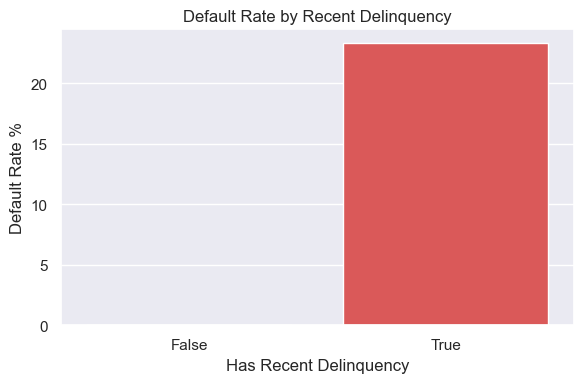

In [21]:
# Plot default rate by delinquency flag.
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=delinquency_summary, x="has_recent_delinquency", y="default_rate", ax=ax, color="#ef4444")
ax.set_title("Default Rate by Recent Delinquency")
ax.set_xlabel("Has Recent Delinquency")
ax.set_ylabel("Default Rate %")
fig.tight_layout()
fig.savefig(figures_dir / "default_rate_by_recent_delinquency.png", dpi=160, bbox_inches="tight")
plt.show()


### Delinquency Result

Missed payments and overdue days are direct repayment-risk indicators. Recent delinquency is one of the strongest warning signals in this data.



## 12. Banking Relationship Segment Risk

This section connects customer segment with loan risk. It helps answer whether Retail, Private Bank, Commercial, or Institutional borrowers carry higher exposure and default pressure.


In [22]:
# Relationship segment risk summary.
financial_segment_summary = (
    df.groupby("banking_relationship", observed=False)
    .agg(
        loans=("loan_id", "count"),
        customers=("customer_id", "nunique"),
        total_exposure=("loan_amount", "sum"),
        median_income=("annual_income", "median"),
        median_deposits=("total_deposit_balance", "median"),
        median_dti=("debt_to_income_ratio", "median"),
        default_rate=("default_flag", "mean"),
        expected_loss=("expected_loss_amount", "sum"),
    )
    .reset_index()
)

financial_segment_summary["default_rate"] = (financial_segment_summary["default_rate"] * 100).round(2)
financial_segment_summary = financial_segment_summary.sort_values("total_exposure", ascending=False)
financial_segment_summary


,banking_relationship,loans,customers,total_exposure,median_income,median_deposits,median_dti,default_rate,expected_loss
3,Retail,6277,5401,"9,776,319,506.21","754,378.82","2,006,021.90",0.53,9.86,"656,429,588.35"
2,Private Bank,2726,2373,"7,975,193,132.94","1,089,020.41","2,957,191.09",0.59,13.02,"607,036,849.86"
0,Commercial,1614,1383,"4,409,810,304.24","1,001,087.74","2,760,002.57",0.70,22.80,"565,021,005.28"
1,Institutional,1294,1122,"2,445,833,935.80","916,026.38","2,517,494.37",0.53,10.51,"163,165,349.18"


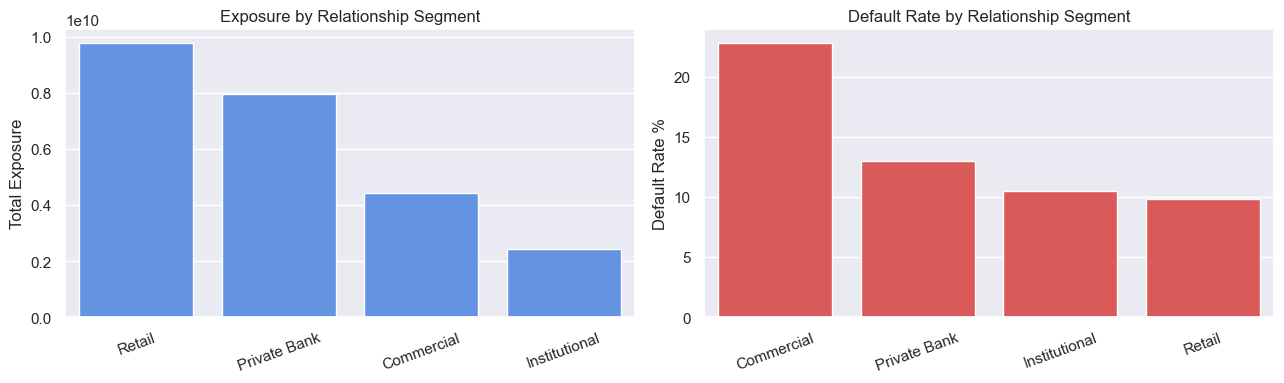

In [23]:
# Plot exposure and default rate by relationship segment.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(data=financial_segment_summary, x="banking_relationship", y="total_exposure", ax=axes[0], color="#4f8ef7")
axes[0].set_title("Exposure by Relationship Segment")
axes[0].set_xlabel("")
axes[0].set_ylabel("Total Exposure")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=financial_segment_summary.sort_values("default_rate", ascending=False), x="banking_relationship", y="default_rate", ax=axes[1], color="#ef4444")
axes[1].set_title("Default Rate by Relationship Segment")
axes[1].set_xlabel("")
axes[1].set_ylabel("Default Rate %")
axes[1].tick_params(axis="x", rotation=20)

fig.tight_layout()
fig.savefig(figures_dir / "relationship_segment_exposure_and_default.png", dpi=160, bbox_inches="tight")
plt.show()


### Relationship Segment Result

Relationship segments show how exposure and risk differ by customer type. A segment can be valuable by deposits but still carry higher loan risk, so both value and risk need to be checked together.



## 13. Expected Loss Concentration

Expected loss combines exposure and risk. It helps prioritize where risk teams should focus first.


In [24]:
# Expected loss concentration by loan type and risk band.
expected_loss_by_loan_type = (
    df.groupby("loan_type", observed=False)
    .agg(expected_loss=("expected_loss_amount", "sum"), total_exposure=("loan_amount", "sum"), loans=("loan_id", "count"))
    .reset_index()
    .sort_values("expected_loss", ascending=False)
)

expected_loss_by_risk_band = (
    df.groupby("risk_band", observed=False)
    .agg(expected_loss=("expected_loss_amount", "sum"), total_exposure=("loan_amount", "sum"), loans=("loan_id", "count"))
    .reset_index()
    .sort_values("expected_loss", ascending=False)
)

expected_loss_by_loan_type["expected_loss_share_pct"] = (expected_loss_by_loan_type["expected_loss"] / expected_loss_by_loan_type["expected_loss"].sum() * 100).round(2)
expected_loss_by_risk_band["expected_loss_share_pct"] = (expected_loss_by_risk_band["expected_loss"] / expected_loss_by_risk_band["expected_loss"].sum() * 100).round(2)

display(expected_loss_by_loan_type)
display(expected_loss_by_risk_band)


,loan_type,expected_loss,total_exposure,loans,expected_loss_share_pct
3,Home Loan,"1,060,504,965.98","17,109,244,490.43",4565,53.25
1,Business Loan,"849,427,806.89","4,939,034,599.08",1929,42.65
4,Personal Loan,"39,672,138.01","1,006,927,560.58",2527,1.99
0,Auto Loan,"31,086,762.81","1,225,358,422.77",2169,1.56
2,Education Loan,"10,961,118.98","326,591,806.33",721,0.55


,risk_band,expected_loss,total_exposure,loans,expected_loss_share_pct
0,High,"1,140,581,973.81","7,389,608,835.83",2144,57.27
2,Medium,"706,216,438.09","10,483,742,729.08",4288,35.46
1,Low,"144,854,380.77","6,733,805,314.28",5479,7.27


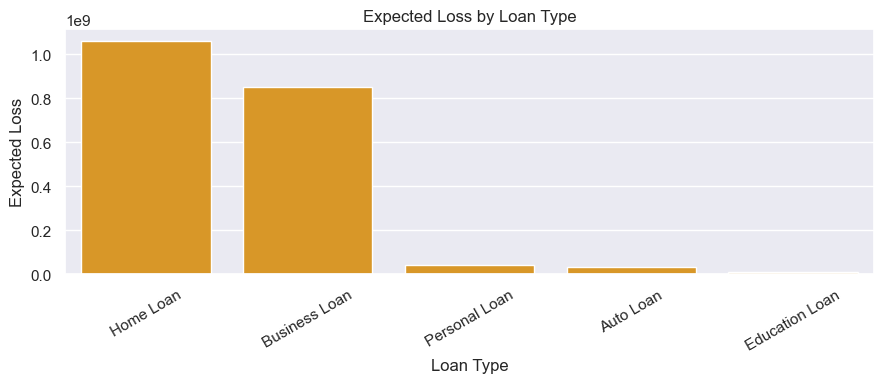

In [25]:
# Plot expected loss by loan type.
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=expected_loss_by_loan_type, x="loan_type", y="expected_loss", ax=ax, color="#f59e0b")
ax.set_title("Expected Loss by Loan Type")
ax.set_xlabel("Loan Type")
ax.set_ylabel("Expected Loss")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
fig.savefig(figures_dir / "expected_loss_by_loan_type.png", dpi=160, bbox_inches="tight")
plt.show()


### Expected Loss Result

Expected loss is more useful than default rate alone because it includes money-at-risk. It shows where the largest potential credit loss is concentrated.



## 14. Correlation Check for Numerical Risk Fields



In [26]:
# Select numerical fields used in lending-risk analysis.
risk_numeric_columns = [
    "loan_amount", "interest_rate", "credit_score", "debt_to_income_ratio",
    "loan_to_value_ratio", "missed_payments_12m", "days_past_due",
    "expected_loss_amount", "default_flag", "annual_income", "total_deposit_balance",
    "credit_utilization_ratio"
]

correlation_matrix = df[risk_numeric_columns].corr(numeric_only=True)
correlation_matrix.round(2)


,loan_amount,interest_rate,credit_score,debt_to_income_ratio,loan_to_value_ratio,missed_payments_12m,days_past_due,expected_loss_amount,default_flag,annual_income,total_deposit_balance,credit_utilization_ratio
loan_amount,1.00,-0.41,-0.26,0.48,-0.01,0.25,0.23,0.65,0.16,0.54,0.45,0.00
interest_rate,-0.41,1.00,0.07,-0.14,0.00,-0.05,-0.03,-0.07,0.00,0.01,0.00,-0.00
credit_score,-0.26,0.07,1.00,-0.54,-0.00,-0.48,-0.43,-0.42,-0.25,-0.02,-0.02,-0.16
debt_to_income_ratio,0.48,-0.14,-0.54,1.00,-0.02,0.51,0.48,0.63,0.34,0.05,0.04,0.00
loan_to_value_ratio,-0.01,0.00,-0.00,-0.02,1.00,0.00,0.02,0.02,0.03,-0.01,-0.02,0.01
missed_payments_12m,0.25,-0.05,-0.48,0.51,0.00,1.00,0.90,0.36,0.62,0.03,0.03,0.07
days_past_due,0.23,-0.03,-0.43,0.48,0.02,0.90,1.00,0.37,0.84,0.03,0.03,0.06
expected_loss_amount,0.65,-0.07,-0.42,0.63,0.02,0.36,0.37,1.00,0.31,0.29,0.24,0.03
default_flag,0.16,0.00,-0.25,0.34,0.03,0.62,0.84,0.31,1.00,0.04,0.03,0.04
annual_income,0.54,0.01,-0.02,0.05,-0.01,0.03,0.03,0.29,0.04,1.00,0.82,-0.00


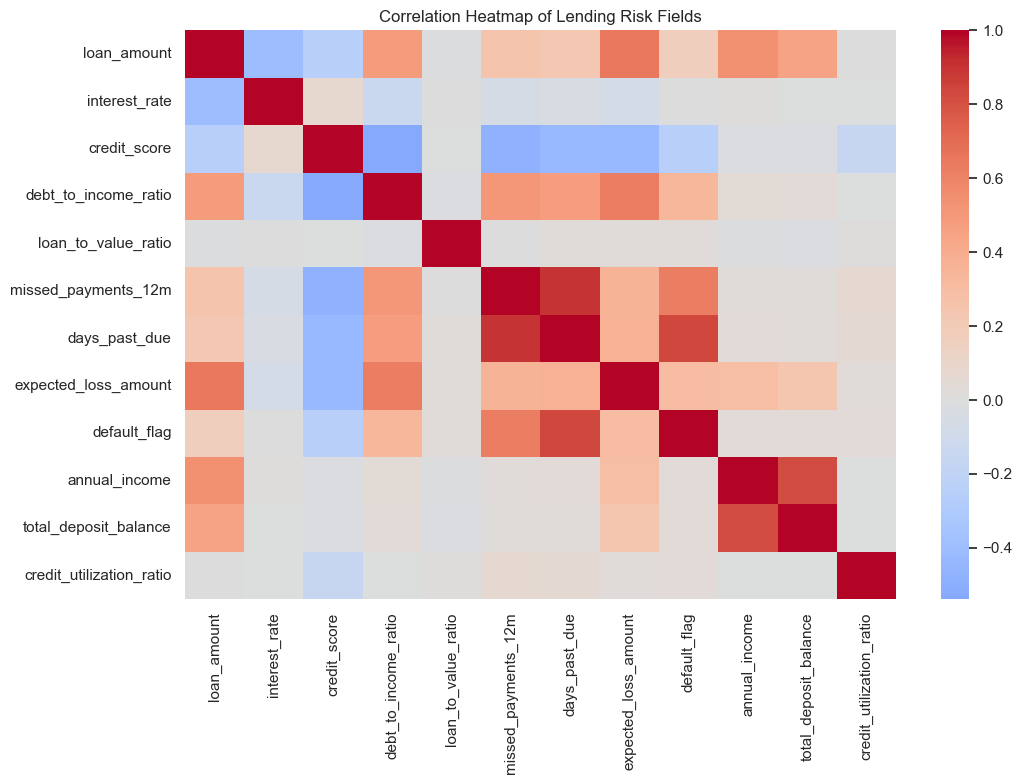

In [27]:
# Plot heatmap of numerical risk correlations.
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, annot=False, ax=ax)
ax.set_title("Correlation Heatmap of Lending Risk Fields")
fig.tight_layout()
fig.savefig(figures_dir / "risk_field_correlation_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()


### Correlation Result

The correlation heatmap is a quick diagnostic view. It helps identify useful risk fields, but final prediction should still be judged through model evaluation.



## 15. Scatter Plot and Heatmap Risk Relationships



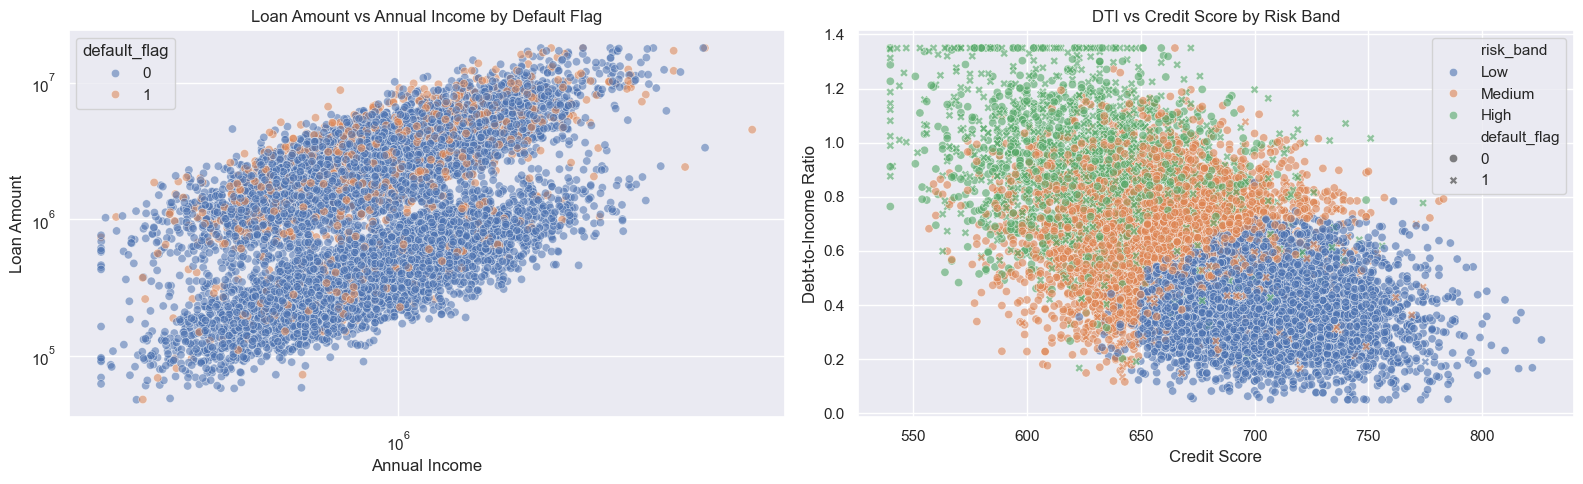

In [28]:
# Scatter plots for borrower-level risk relationships.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.scatterplot(
    data=df,
    x="annual_income",
    y="loan_amount",
    hue="default_flag",
    alpha=0.55,
    ax=axes[0],
)
axes[0].set_title("Loan Amount vs Annual Income by Default Flag")
axes[0].set_xlabel("Annual Income")
axes[0].set_ylabel("Loan Amount")
axes[0].set_xscale("log")
axes[0].set_yscale("log")

sns.scatterplot(
    data=df,
    x="credit_score",
    y="debt_to_income_ratio",
    hue="risk_band",
    style="default_flag",
    alpha=0.6,
    ax=axes[1],
)
axes[1].set_title("DTI vs Credit Score by Risk Band")
axes[1].set_xlabel("Credit Score")
axes[1].set_ylabel("Debt-to-Income Ratio")

fig.tight_layout()
fig.savefig(figures_dir / "risk_scatter_relationships.png", dpi=160, bbox_inches="tight")
plt.show()



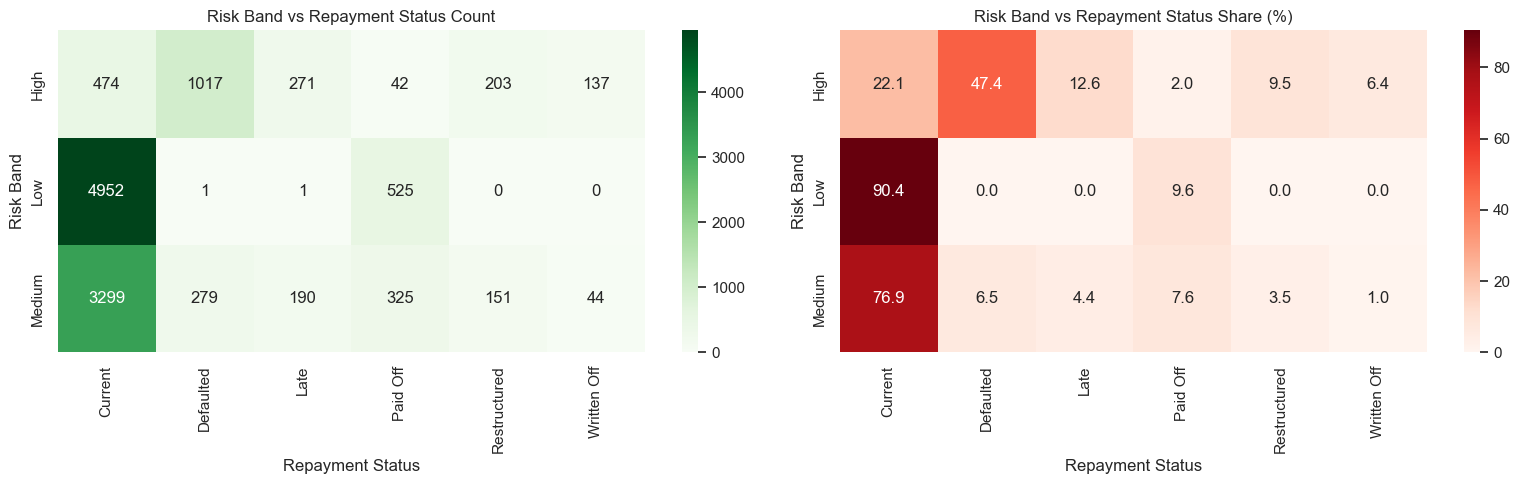

repayment_status,Current,Defaulted,Late,Paid Off,Restructured,Written Off
risk_band,,,,,,
High,474,1017,271,42,203,137
Low,4952,1,1,525,0,0
Medium,3299,279,190,325,151,44


repayment_status,Current,Defaulted,Late,Paid Off,Restructured,Written Off
risk_band,,,,,,
High,22.11,47.43,12.64,1.96,9.47,6.39
Low,90.38,0.02,0.02,9.58,0.00,0.00
Medium,76.94,6.51,4.43,7.58,3.52,1.03


In [29]:
# Heatmap: risk band vs repayment status.
risk_repayment_matrix = pd.crosstab(
    df["risk_band"],
    df["repayment_status"],
)

risk_repayment_pct = pd.crosstab(
    df["risk_band"],
    df["repayment_status"],
    normalize="index",
).mul(100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(risk_repayment_matrix, annot=True, fmt="d", cmap="Greens", ax=axes[0])
axes[0].set_title("Risk Band vs Repayment Status Count")
axes[0].set_xlabel("Repayment Status")
axes[0].set_ylabel("Risk Band")

sns.heatmap(risk_repayment_pct, annot=True, fmt=".1f", cmap="Reds", ax=axes[1])
axes[1].set_title("Risk Band vs Repayment Status Share (%)")
axes[1].set_xlabel("Repayment Status")
axes[1].set_ylabel("Risk Band")

fig.tight_layout()
fig.savefig(figures_dir / "risk_band_repayment_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

display(risk_repayment_matrix)
display(risk_repayment_pct)



### Scatter and Heatmap Result

The scatter plots show borrower-level spread instead of only group averages. The heatmap shows that bad repayment outcomes are concentrated more heavily in the high-risk band.



## 16. Final Lending Risk Insights

This section keeps the main lending-risk findings in one place.



In [30]:
# Extract final insight values.
highest_exposure_loan_type = loan_type_summary.sort_values("total_exposure", ascending=False).iloc[0]
highest_default_loan_type = loan_type_summary.sort_values("default_rate", ascending=False).iloc[0]
highest_risk_band = risk_band_summary.sort_values("default_rate", ascending=False).iloc[0]
highest_dti_band = default_by_dti.sort_values("default_rate", ascending=False).iloc[0]
highest_segment_default = financial_segment_summary.sort_values("default_rate", ascending=False).iloc[0]
highest_expected_loss_type = expected_loss_by_loan_type.sort_values("expected_loss", ascending=False).iloc[0]

lending_risk_insights = pd.DataFrame([
    {
        "insight": "Largest exposure product",
        "result": f"{highest_exposure_loan_type['loan_type']} with INR {highest_exposure_loan_type['total_exposure'] / 10_000_000:.2f} crore exposure"
    },
    {
        "insight": "Highest default-rate product",
        "result": f"{highest_default_loan_type['loan_type']} with {highest_default_loan_type['default_rate']:.2f}% default rate"
    },
    {
        "insight": "Highest risk band default rate",
        "result": f"{highest_risk_band['risk_band']} risk with {highest_risk_band['default_rate']:.2f}% default rate"
    },
    {
        "insight": "Highest DTI band default rate",
        "result": f"{highest_dti_band['dti_band']} DTI with {highest_dti_band['default_rate']:.2f}% default rate"
    },
    {
        "insight": "Highest default-rate relationship segment",
        "result": f"{highest_segment_default['banking_relationship']} with {highest_segment_default['default_rate']:.2f}% default rate"
    },
    {
        "insight": "Highest expected-loss product",
        "result": f"{highest_expected_loss_type['loan_type']} with INR {highest_expected_loss_type['expected_loss'] / 10_000_000:.2f} crore expected loss"
    },
])

lending_risk_insights


,insight,result
0,Largest exposure product,Home Loan with INR 1710.92 crore exposure
1,Highest default-rate product,Business Loan with 30.79% default rate
2,Highest risk band default rate,High risk with 53.82% default rate
3,Highest DTI band default rate,>60% DTI with 21.78% default rate
4,Highest default-rate relationship segment,Commercial with 22.80% default rate
5,Highest expected-loss product,Home Loan with INR 106.05 crore expected loss


### Insight Table Result

The final table summarizes where exposure is largest, where default risk is highest, and where expected loss is concentrated.



## 17. Export Analysis Tables


In [31]:
# Export all analysis tables for reporting.
portfolio_kpis.to_csv(tables_dir / "portfolio_kpis.csv", index=False)
portfolio_kpis_readable.to_csv(tables_dir / "portfolio_kpis_readable.csv", index=False)
loan_type_summary.to_csv(tables_dir / "loan_type_summary.csv", index=False)
repayment_summary.to_csv(tables_dir / "repayment_status_summary.csv", index=False)
risk_band_summary.to_csv(tables_dir / "risk_band_summary.csv", index=False)
default_by_dti.to_csv(tables_dir / "default_by_dti_band.csv", index=False)
default_by_credit.to_csv(tables_dir / "default_by_credit_score_band.csv", index=False)
default_by_ltv.to_csv(tables_dir / "default_by_ltv_band.csv", index=False)
delinquency_summary.to_csv(tables_dir / "delinquency_summary.csv", index=False)
financial_segment_summary.to_csv(tables_dir / "financial_segment_summary.csv", index=False)
expected_loss_by_loan_type.to_csv(tables_dir / "expected_loss_by_loan_type.csv", index=False)
expected_loss_by_risk_band.to_csv(tables_dir / "expected_loss_by_risk_band.csv", index=False)
correlation_matrix.to_csv(tables_dir / "risk_field_correlation_matrix.csv")
lending_risk_insights.to_csv(tables_dir / "lending_risk_insights.csv", index=False)
risk_distribution_summary.reset_index(names="metric").to_csv(tables_dir / "risk_distribution_summary.csv", index=False)
risk_repayment_matrix.to_csv(tables_dir / "risk_repayment_matrix.csv")
risk_repayment_pct.to_csv(tables_dir / "risk_repayment_pct.csv")

exported_tables = pd.DataFrame([
    {"table": "loan_type_summary.csv", "purpose": "loan product exposure and default-rate comparison"},
    {"table": "risk_band_summary.csv", "purpose": "risk band exposure, default rate, and expected loss"},
    {"table": "default_by_dti_band.csv", "purpose": "DTI-based default-rate analysis"},
    {"table": "financial_segment_summary.csv", "purpose": "relationship segment lending-risk analysis"},
    {"table": "lending_risk_insights.csv", "purpose": "final interview-ready lending-risk insights"},
])

exported_tables


,table,purpose
0,loan_type_summary.csv,loan product exposure and default-rate comparison
1,risk_band_summary.csv,"risk band exposure, default rate, and expected..."
2,default_by_dti_band.csv,DTI-based default-rate analysis
3,financial_segment_summary.csv,relationship segment lending-risk analysis
4,lending_risk_insights.csv,final interview-ready lending-risk insights


### Saved Outputs

The financial exposure and lending-risk tables and charts were saved successfully.



## 18. Final Summary

I analyzed the loan-level data to understand portfolio exposure, repayment status, default risk, and expected loss.

### Portfolio Size

- loan records: 11,911
- customers with loans: 10,279
- total loan exposure: INR 2460.72 crore
- median loan amount: INR 1,242,368
- overall default rate: 12.41%
- total expected loss: INR 199.17 crore

### Loan Types

The largest exposure is in Home Loans:

- Home Loan exposure: INR 1710.92 crore
- Home Loan default rate: 13.21%

The highest default-rate product is Business Loan:

- Business Loan exposure: INR 493.90 crore
- Business Loan default rate: 30.79%

Home Loans carry the largest money exposure, while Business Loans are riskier by default rate.

### Repayment Status

Repayment status count:

- Current: 8,725 loans
- Defaulted: 1,297 loans
- Paid Off: 892 loans
- Late: 462 loans
- Restructured: 354 loans
- Written Off: 181 loans

Most loans are current. The main risk pool is Defaulted, Written Off, Late, and Restructured loans.

### Risk Bands

Default rate by risk band:

- High: 53.82%
- Medium: 7.53%
- Low: 0.02%

The high-risk band has a much higher default rate, so the risk band is useful.

### Debt-to-Income Ratio

Default rate by DTI band:

- <=35%: 2.93%
- 35-45%: 3.86%
- 45-60%: 6.97%
- >60%: 21.78%

Borrowers with DTI above 60% are clearly riskier.

### Delinquency

Recent delinquency is a strong warning signal:

- no recent delinquency: 0.00% default rate
- recent delinquency: 23.31% default rate

Missed payments and days past due are directly connected with default risk.

### Relationship Segments

Default rate by relationship segment:

- Commercial: 22.80%
- Private Bank: 13.02%
- Institutional: 10.51%
- Retail: 9.86%

Retail has a large loan base, but Commercial customers show higher default pressure.

### Visual Findings

The histograms show loan amount, income, and expected loss are right-skewed. The boxplots show large loans and high expected-loss cases, which are important and should not be removed blindly.

The scatter plots show how loan amount, income, credit score, DTI, risk band, and default flag vary by borrower. The heatmap shows weak repayment outcomes are more common in the high-risk band.

### What This Shows

Risk is not coming from one field only. The strongest warning patterns are high DTI, recent delinquency, high-risk band, and Business Loan exposure. Home Loans dominate total exposure, while Business Loans and high-DTI borrowers need closer monitoring.
